In [ ]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from tqdm.notebook import tqdm
import dask.bag as db
from pyproj import Proj, Transformer, CRS

import pandas as pd
plt.style.use('robin')
proj = ccrs.NorthPolarStereo(0,70)
import cmocean.cm as cm
import matplotlib.animation as animation
from scipy.ndimage import center_of_mass
import matplotlib as mpl
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [2]:
import hvplot.xarray

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from svgpath2mpl import parse_path

def marker_from_svg(svg_file):
    tree = ET.parse(svg_file)
    root = tree.getroot()
    # find first <path> element (SVGs often have namespaces)
    ns = {'svg': 'http://www.w3.org/2000/svg'}
    p = root.find('.//svg:path', ns)
    if p is None:
        raise ValueError("No <path> element found in SVG.")
    d = p.attrib['d']
    path = parse_path(d)
    # normalize around origin so it behaves like a marker
    path.vertices -= path.vertices.mean(axis=0)
    marker = mpl.transforms.Affine2D().scale(-1, 1).transform_path(path)
    return path

marker = marker_from_svg("../diagnostics_newproj/plots/plots_leadai/cyclone_symbol.svg")

In [4]:
cluster = LocalCluster(n_workers=8, memory_limit='12GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 64,Total memory: 96.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40007,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35681,Total threads: 8
Dashboard: http://127.0.0.1:34197/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:33029,


In [5]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'

run_id = '75kakckt'

# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc', chunks = dict(time_of_event=20)).load().transpose('y','x',...)

grid = ds_attrs.isel(time_of_event=0, timestep_past=0, var_name=0).features
lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed
ig_normed = ds_attrs.attributions_ig 
ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# cycs = cycs.query("msl<100000")
ds_attrs

<xarray.Dataset> Size: 6GB
Dimensions:           (time_of_event: 937, y: 128, x: 128, timestep_past: 7,
                       var_name: 4)
Coordinates:
    quantile          float64 8B 0.95
  * y                 (y) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * x                 (x) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * var_name          (var_name) <U4 64B 'u850' 'v850' 'msl' 'z500'
    lat               (y, x) float32 66kB -7.882 -7.546 -7.21 ... 31.67 31.09
    lon               (y, x) float32 66kB -45.0 -44.66 -44.32 ... 135.7 135.0
  * timestep_past     (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
  * time_of_event     (time_of_event) datetime64[ns] 7kB 1979-01-07 ... 2025-...
Data variables:
    rain              (time_of_event) float64 7kB 30.89 37.58 ... 23.69 27.42
    targets           (time_of_event) float64 7kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    features          (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    attributions_lrp  (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    predictions       (time_of_event, timestep_past) float32 26kB -0.5857 ......
    attributions_ig   (y, x, time_of_event, timestep_past, var_name) float32 2GB ...
    lrp_normed        (y, x, time_of_event, timestep_past) float32 430MB 0.0 ...

In [6]:
all_df_dailys = []
import glob
files = glob.glob('/Data/gfi/share/Reanalyses/ERA-5/detected_features/cyclone_tracks_melbourne/*.pos.nc')
files = [f for f in files if f.endswith('.nc')]
for file in tqdm(files):
    with xr.open_dataset(file) as ds:
        df_ = ds[['track_id', 'lon','lat','msl','date']].to_dataframe()
        df_['date'] = pd.to_datetime(df_.date.dt.date)
        df_daily = df_.groupby(['date','track_id']).agg({'msl':'min','lon':'mean','lat':'mean'}).reset_index()   
        all_df_dailys.append(df_daily)
        del df_
daily_cycs = pd.concat(all_df_dailys)
proj_stereo = CRS(f"+proj=stere +lat_0=90 +lat_ts=70 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +units=m")
transformer = Transformer.from_crs("EPSG:4326", proj_stereo, always_xy=True)
# x,y = lonlat_to_northpolarstereo(cycs['lon'].values, cycs['lat'].values, central_longitude=0, latitude_of_true_scale=70)
x,y = transformer.transform(daily_cycs['lon'].values, daily_cycs['lat'].values)
daily_cycs['x'] = x
daily_cycs['y'] = y
daily_cycs = daily_cycs.loc[(daily_cycs.x > -1e7)&(daily_cycs.x < 5e6)&(daily_cycs.y > -1e7)&(daily_cycs.y < 5e6)]

time_min = pd.to_datetime(ds_attrs.time_of_event.min().values - pd.Timedelta('7D'))
time_max = pd.to_datetime(ds_attrs.time_of_event.max().values)

daily_cycs = daily_cycs.loc[(daily_cycs.date>=time_min) & (daily_cycs.date<=time_max)]
daily_cycs = daily_cycs.set_index('date').sort_index()
daily_cycs['track_id']=daily_cycs['track_id'].astype(int).astype(float)

  0%|          | 0/552 [00:00<?, ?it/s]

In [7]:
palette1 = sns.choose_diverging_palette()

interactive(children=(IntSlider(value=220, description='h_neg', max=359), IntSlider(value=10, description='h_p…

In [8]:
palette = sns.color_palette('icefire', n_colors=11)
palette[5]=[0,0,0]
palette = sns.color_palette(palette, as_cmap=True)
palette

[(0.50555676, 0.74804469, 0.81063503),
 (0.27923924, 0.59522877, 0.80669803),
 (0.25423116, 0.40433127, 0.78155831),
 (0.2659204, 0.25949691, 0.511417),
 (0.16868273, 0.16479861, 0.25034479),
 [0, 0, 0],
 (0.25546457, 0.13661751, 0.16248722),
 (0.47151732, 0.17401641, 0.24610337),
 (0.72401436, 0.20691287, 0.25027366),
 (0.8866469, 0.37249496, 0.1997976),
 (0.95471709, 0.60510869, 0.37236035)]

/tmp/ipykernel_2033134/2602000443.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap('icefire', 256)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/matplotlib/transforms.py:2003: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self.rotate(math.radians(degrees))


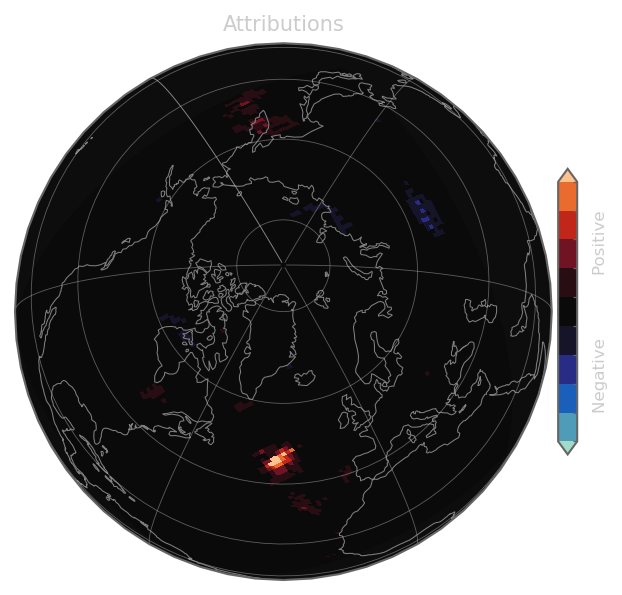

In [52]:
cyc_=778065

timestep = -4
data = ds_attrs.sel(time_of_event='2016-08-09').attributions_lrp.sum('var_name').sel(timestep_past=timestep)
time = (data.time_of_event + pd.Timedelta('1D')*timestep).values

cycs = daily_cycs.query("track_id==@cyc_")
data = data /data.max()
plot =data.clip(max=.9999).plot( subplot_kws=dict(projection=ccrs.Orthographic(-30,80)), transform=proj,  extend='both',
                   cbar_kwargs=dict(shrink=.4, aspect=15, label='Normalized features', pad=0.01),
                   size=5,
                   levels=np.arange(-.9,1,.2),
                   aspect=.9,
                     zorder=0,
                     colors=accentuate_icefire(strength=1.5))
ax = plot.axes
# for ax in plot.axs.flat:
ax.coastlines(color='.5', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
# sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2
)
ax.set_title('Attributions', color='.8')
plot.colorbar.ax.set_yticks([])
plot.colorbar.ax.set_ylabel('Negative            Positive', loc='center', color='.8')

daily_cycs.query("track_id==@cyc_")
ax.set_facecolor('0.05')
marker = marker_from_svg("../diagnostics_newproj/plots/plots_leadai/cyclone_symbol.svg")
marker = mpl.markers.MarkerStyle(marker=mpl.transforms.Affine2D().scale(-1, 1).translate(-10, 60.0).transform_path(marker))
marker._transform = marker.get_transform().rotate_deg(cycs.loc[[time]].lon+140)
# cycs.loc[[time]].plot.scatter(x='x',y='y', marker=marker, s = 1000, color='none', edgecolor='.7', linewidth=1,ax=ax, transform=proj)
# cycs.loc[[time]].plot.scatter(x='x',y='y', marker='o', s = 5, color='.7', edgecolor='.7', linewidth=1,ax=ax, transform=proj)
ax.set_global()
plt.tight_layout()
# plot.colorbar.ax.set_ylabel('Positive', loc='top')
plt.savefig('plots/plots_leadai/attributions.png',dpi=300, transparent=True )

In [10]:
ds_ = xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr/').sel(time='2016-08-05')

In [16]:
wind_speed = np.sqrt((ds_[['u850','v850']].to_array('var_name')**2).sum('var_name'))

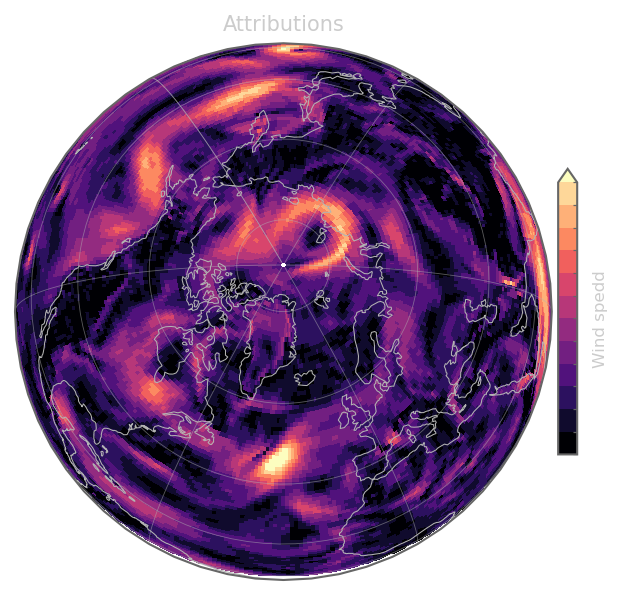

In [53]:
plot =wind_speed.plot( subplot_kws=dict(projection=ccrs.Orthographic(-30,80)), transform=ccrs.PlateCarree(), 
                   cbar_kwargs=dict(shrink=.4, aspect=15, label='Normalized features', pad=0.01),
                   size=5,
                   levels=np.arange(0,26,2),
                   aspect=.9,
                     zorder=0,
                     cmap='magma')
ax = plot.axes
# for ax in plot.axs.flat:
ax.coastlines(color='.7', lw=.5)
# sns.lineplot(daily_cycs.query("track_id=='778065'"), x='x', y='y', transform=proj,ax=ax)
# sns.scatterplot(daily_cycs.loc[['2016-08-05']].query('msl<100000'), x='x', y='y', transform=proj,ax=ax, color='none')
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,       # add tick labels
    linewidth=0.4,
    linestyle="-",
    alpha=0.5,
    zorder=2,
    color='.7'
)
ax.set_title('Attributions', color='.8')
plot.colorbar.ax.set_yticks([])
plot.colorbar.ax.set_ylabel('Wind spedd', loc='center', color='.8')
ax.set_global()
plt.tight_layout()

plt.savefig('plots/plots_leadai/wind_speed_example.png',dpi=300, transparent=True )

In [44]:
from matplotlib import cm, colors

def accentuate_icefire(strength=1.5):
    """
    Create a modified version of the 'icefire' colormap with
    a darker center and lighter edges.
    
    strength > 1 => more extreme effect.
    """
    base = cm.get_cmap('icefire', 256)
    colors_array = base(np.linspace(0, 1, 256))
    
    # Compute luminance (perceived brightness)
    lum = 0.2126 * colors_array[:, 0] + 0.7152 * colors_array[:, 1] + 0.0722 * colors_array[:, 2]
    
    # Create a non-linear adjustment curve: darken middle, lighten ends
    x = np.linspace(0, 1, 256)
    adjust = np.abs(x - 0.5) ** (1 / strength)
    adjust = (adjust - adjust.min()) / (adjust.max() - adjust.min())
    
    # Blend each channel toward black (middle) or white (edges)
    adjusted_colors = colors_array.copy()
    for i in range(3):  # RGB channels
        adjusted_colors[:, i] = np.clip(colors_array[:, i] * adjust + (1 - adjust) * colors_array[:, i], 0, 1)
    
    # Make middle darker and ends lighter explicitly
    adjusted_colors[:, :3] = adjusted_colors[:, :3] ** strength
    
    return colors.LinearSegmentedColormap.from_list('icefire_accent', adjusted_colors)

# Example usage
accented_cmap = accentuate_icefire(strength=1.8)

/tmp/ipykernel_2033134/2602000443.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap('icefire', 256)


In [56]:
from matplotlib import cm
import numpy as np

def remap_colormap(cmap_name='icefire', power=0.5):
    cmap = cm.get_cmap(cmap_name)
    colors = cmap(np.linspace(0, 1, 256))
    new_positions = np.linspace(0, 1, 256) ** power
    new_cmap = cm.colors.LinearSegmentedColormap.from_list('icefire_remap', list(zip(new_positions, colors)))
    return new_cmap

custom_cmap = remap_colormap('icefire', power=0.5)


/tmp/ipykernel_1252701/1596123445.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


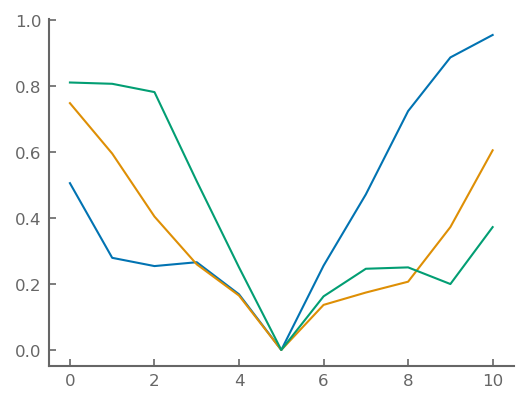

In [52]:
plt.plot(np.array(palette)[:,0])
plt.plot(np.array(palette)[:,1])
plt.plot(np.array(palette)[:,2])

In [124]:
daily_cycs.query("timestep_past=@time")

ValueError: cannot assign without a target object

In [122]:
daily_cycs.query("track_id==@cyc_")

,track_id,msl,lon,lat,x,y
date,,,,,,
2016-08-03,778065.0,100760.219965,-59.473884,38.974797,-5.090409e+06,-3.001606e+06
2016-08-04,778065.0,99704.904662,-48.503729,40.786021,-4.248235e+06,-3.758028e+06
2016-08-05,778065.0,98907.217938,-36.994501,45.511965,-3.049106e+06,-4.047108e+06
2016-08-06,778065.0,98718.172573,-23.578842,55.209346,-1.553775e+06,-3.560033e+06
2016-08-07,778065.0,98236.550362,-8.869535,61.247454,-4.901695e+05,-3.141083e+06
2016-08-08,778065.0,98335.301292,2.082091,63.093586,1.078063e+05,-2.965349e+06
2016-08-09,778065.0,99123.806536,8.121788,63.623124,4.106737e+05,-2.877699e+06


In [112]:
daily_cycs.query("track_id==@cyc_").daily_cycs

AttributeError: 'DataFrame' object has no attribute 'daily_cycs'

In [118]:
import geopandas as gpd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from svgpath2mpl import parse_path

def marker_from_svg(svg_file):
    tree = ET.parse(svg_file)
    root = tree.getroot()
    # find first <path> element (SVGs often have namespaces)
    ns = {'svg': 'http://www.w3.org/2000/svg'}
    p = root.find('.//svg:path', ns)
    if p is None:
        raise ValueError("No <path> element found in SVG.")
    d = p.attrib['d']
    path = parse_path(d)
    # normalize around origin so it behaves like a marker
    path.vertices -= path.vertices.mean(axis=0)
    marker = mpl.transforms.Affine2D().scale(-1, 1).transform_path(path)
    return path

marker = marker_from_svg("../diagnostics_newproj/plots/plots_leadai/cyclone_symbol.svg")

In [56]:
import geopandas as gpd

<Axes: xlabel='x', ylabel='y'>

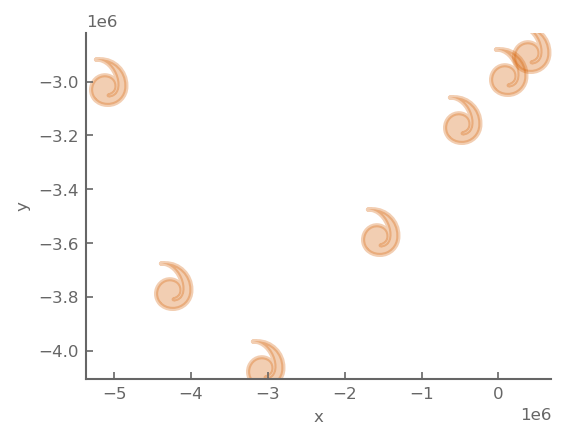

In [82]:
daily_cycs.query("track_id==@cyc_").plot.scatter(x='x',y='y', marker=marker, s = 500, color='C3', alpha=.3, edgecolor='C3', linewidth=2)

In [86]:
time = pd.to_datetime('2016-08-09')
da = ds_attrs.attributions_lrp.sel(time_of_event=time).rename(timestep_past='time').sum('var_name')
cyc_=778065

In [88]:
da.hvplot(groupby='time', geo=True, crs=proj, projection=proj, coastline=True, cmap='icefire', vmax=.03)

BokehModel(combine_events=True, render_bundle={'docs_json': {'3826d8fa-90ff-41c8-a128-97b103e3183b': {'version…

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


AttributeError: QuadMesh.set() got an unexpected keyword argument 'levels'

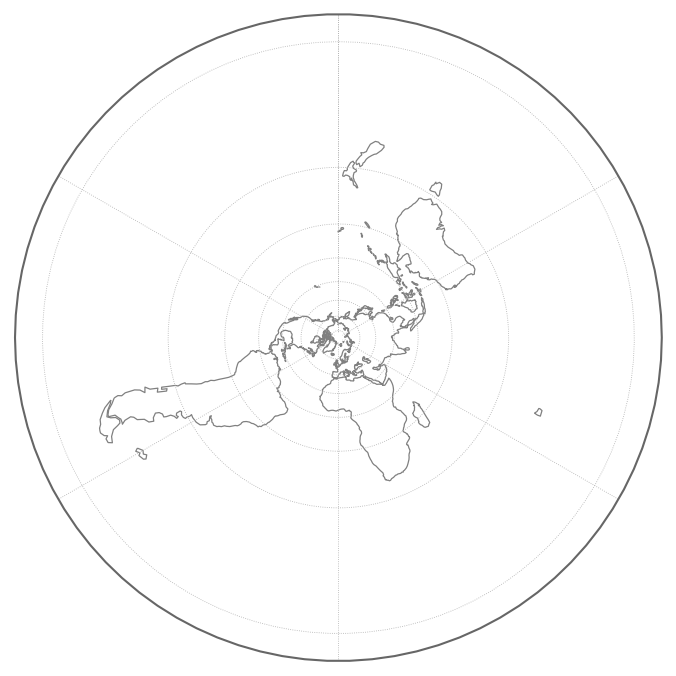

In [40]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assume da is as defined above (time × lat × lon)

proj_data = proj         # data are in lon/lat
proj_map  = proj  # pick what suits your region

vmin = -0.01
vmax = 0.01

fig = plt.figure(figsize=(7.2, 5.6))
ax = plt.axes(projection=proj_map)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='.5')
# ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=False, linewidth=0.4, x_inline=False, y_inline=False)

# Optional: focus on a region (e.g., Western Norway & N Atlantic)
# ax.set_extent([-20, 20, 55, 72], crs=proj_data)

# Initial frame
mesh = ax.pcolormesh(
    da.x, da.y, da.isel(time=4),
    transform=proj_data, shading="auto", vmin=vmin, vmax=vmax,
    cmap='icefire', levels=np.arange(-0.01,0.011,0.001)
)
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, fraction=0.05, shrink=.6, extend='both')
cbar.set_label(da.name)
ttl = ax.set_title(f"{da.name} — {str(da.time.values[0])}")

def update(i):
    frame = da.isel(time=i)
    # Update the mesh efficiently:
    mesh.set_array(frame.values[:-1, :-1].ravel() if mesh.get_array().size != frame.values.size else frame.values.ravel())
    ttl.set_text(f"{da.name} — {str(frame.time.values)}")
    return (mesh, ttl)

anim = FuncAnimation(fig, update, frames=da.sizes["time"], interval=800, blit=False)

# Save (MP4)
# writer = FFMpegWriter(fps=8, bitrate=1800)
anim.save("animated_map_cartopy.gif", dpi=150)

plt.close(fig)


In [8]:
anim

In [110]:
from xmovie import Movie
mov = Movie(lrp_normed.sel(time_of_event=time).rename(timestep_past='time'))
mov.save('../plots_leadai/movie_slow.gif', remove_movie=False, progress=True, framerate=5, gif_framerate=5)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xmovie/core.py:46: UserWarning: No `vmin` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `vmin` to avoid this step
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/xmovie/core.py:53: UserWarning: No `vmax` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `vmax` to avoid this step
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

No ffmpeg found


/bin/sh: ffmpeg: command not found


RuntimeError: Could not find an ffmpeg version on the system.         Please install ffmpeg with e.g. `conda install -c conda-forge ffmpeg`

In [ ]:
time = pd.to_datetime('2016-08-09')
cyc_='778065'

all_important = []
for k in range(7):
    time_ = time +(k-6)*pd.Timedelta('1D')
    cyclones_ = daily_cycs.loc[time +(k-6)*pd.Timedelta('1D')].copy().set_index('track_id')
    important_cyclones_ = important_cyclones.sel(time_of_event=time).isel(timestep_past=k).tracks.dropna('n_cyclone').values
    important_cyclones_ = cyclones_.loc[important_cyclones_]
    important_cyclones_['attribution2000'] = important_cyclones.sel(time_of_event=time).isel(timestep_past=k).attributions2000.dropna('n_cyclone').values
    important_cyclones_['timestep_past'] = (k-6) 
    all_important.append(important_cyclones_)
important_cyclones_tracks = pd.concat(all_important).reset_index()
important_cyclones_tracks['track_id']=important_cyclones_tracks['track_id'].astype(str)

palette = sns.color_palette('tab20')

# colors = {id:palette[k] for k,id in enumerate(importaxnt_cyclones_tracks.track_id.unique())}
# # colors
data = ((lrp_normed.sel(time_of_event=time)))/(lrp_normed.sel(time_of_event=time)).quantile(0.999,['x','y','timestep_past'])
plot = data.plot(x='x',y='y',col='timestep_past', 
                 subplot_kws=dict(projection=proj), transform=proj,
                 size=3, aspect=1, cmap='icefire', vmax=1.5, rasterized=True)
for k, ax in enumerate(plot.axs.flat):
    ax.coastlines(color='.5', lw=.5)
    time_ = time +(k-6)*pd.Timedelta('1D')
    ax.set_title(f"{time_.strftime('%Y-%m-%d')}")
    # sns.lineplot(important_cyclones_tracks.sort_values('timestep_past'), x='x',y='y', sort=False, hue='track_id',ax=ax)
    sns.lineplot(important_cyclones_tracks.query("track_id==@cyc_")
                    ,x='x', y='y', color='.6', linewidth=1, zorder=10, transform=proj,ax=ax, legend=False, sort=False, marker='o', markeredgecolor='none', markersize=3)
    timestep_past = (k-6)
    sns.scatterplot(important_cyclones_tracks.query("(timestep_past==@timestep_past)&(track_id==@cyc_)")
                    ,x='x', y='y', s=200,edgecolor='1',zorder=100, linewidth=1, transform=proj,ax=ax, legend=True,
                    color=None, facecolor='none')
    ax.set_extent((ds_attrs.x.min(),ds_attrs.x.max(),ds_attrs.y.min(),ds_attrs.y.max(),), crs=proj)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,       # add tick labels
        linewidth=0.4,
        linestyle="-",
        alpha=0.5,
        zorder=2
    )
# plt.suptitle(time)
plt.savefig('plots/plots_leadai/cyclonetracking.pdf', dpi=300)

In [22]:
def gini(x):
    v = np.asarray(x, dtype=float).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    v = np.abs(v)
    s = v.sum()
    if s == 0:
        return 0.0
    v.sort()
    n = v.size
    cum = np.cumsum(v)
    # Gini = (n + 1 - 2 * sum(cum/s)) / n
    return (n + 1 - 2.0 * np.sum(cum) / s) / n

lrp_gini = xr.apply_ufunc(
            gini, lrp_normed,
            input_core_dims=[['x','y']],
            output_core_dims=[[]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
        )

In [65]:
def com2d(a):
    x,y = np.array(center_of_mass(np.abs(a)))
    return np.array([lrp_normed.x.isel(x=x.astype(int)).values, lrp_normed.y.isel(y=y.astype(int)).values])

def center_of_mass_da(da, spatial_dims=["lat", "lon"]):
    return xr.apply_ufunc(
        com2d, da,
        input_core_dims=[spatial_dims],
        output_core_dims=[["coord"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        output_sizes={"coord": 2},
    ).assign_coords(coord=["lat_index", "lon_index"])

center_of_mass_lrp = center_of_mass_da(lrp_normed, spatial_dims=['x','y'])
motion_lrp_center = np.sqrt((center_of_mass_lrp.diff('timestep_past')**2).sum('coord'))

/tmp/ipykernel_1159446/1377652084.py:6: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  return xr.apply_ufunc(


In [67]:
ds_ = xr.Dataset(dict(motion=motion_lrp_center,  gini=lrp_gini))

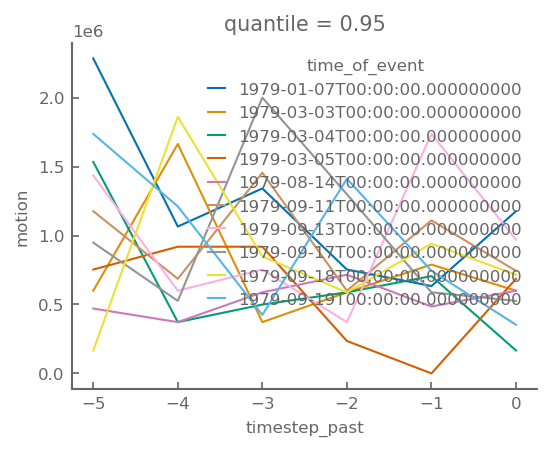

In [72]:
ds_.motion.isel(time_of_event=range(10)).plot(hue='time_of_event')

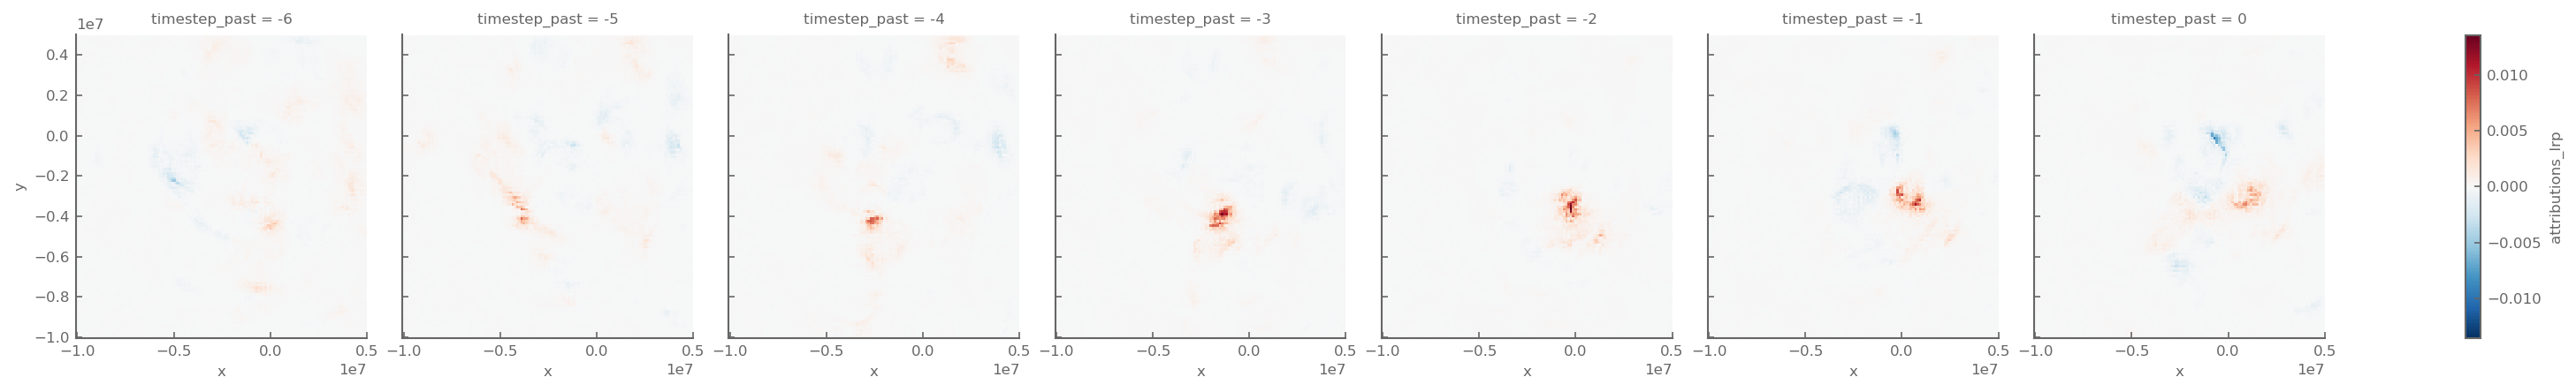

In [79]:
lrp_normed.sel(time_of_event='2016-08-09').plot(col='timestep_past')

In [35]:
lrp_gini.mean('timestep_past').to_series().sort_values().iloc[-20:]

time_of_event
2008-10-26    0.899124
1986-11-10    0.899503
2017-11-09    0.899651
2020-02-17    0.899884
2018-09-20    0.899983
2015-12-05    0.900485
2008-10-20    0.900485
1996-10-12    0.900878
2015-12-04    0.901316
2001-10-03    0.901504
2015-10-22    0.902948
2008-10-23    0.903807
1999-11-01    0.904008
1986-10-19    0.904322
1983-10-05    0.904933
1999-10-31    0.905914
2008-10-25    0.906833
2008-10-24    0.910080
1986-11-09    0.913896
1986-11-08    0.920553
Name: attributions_lrp, dtype: float64

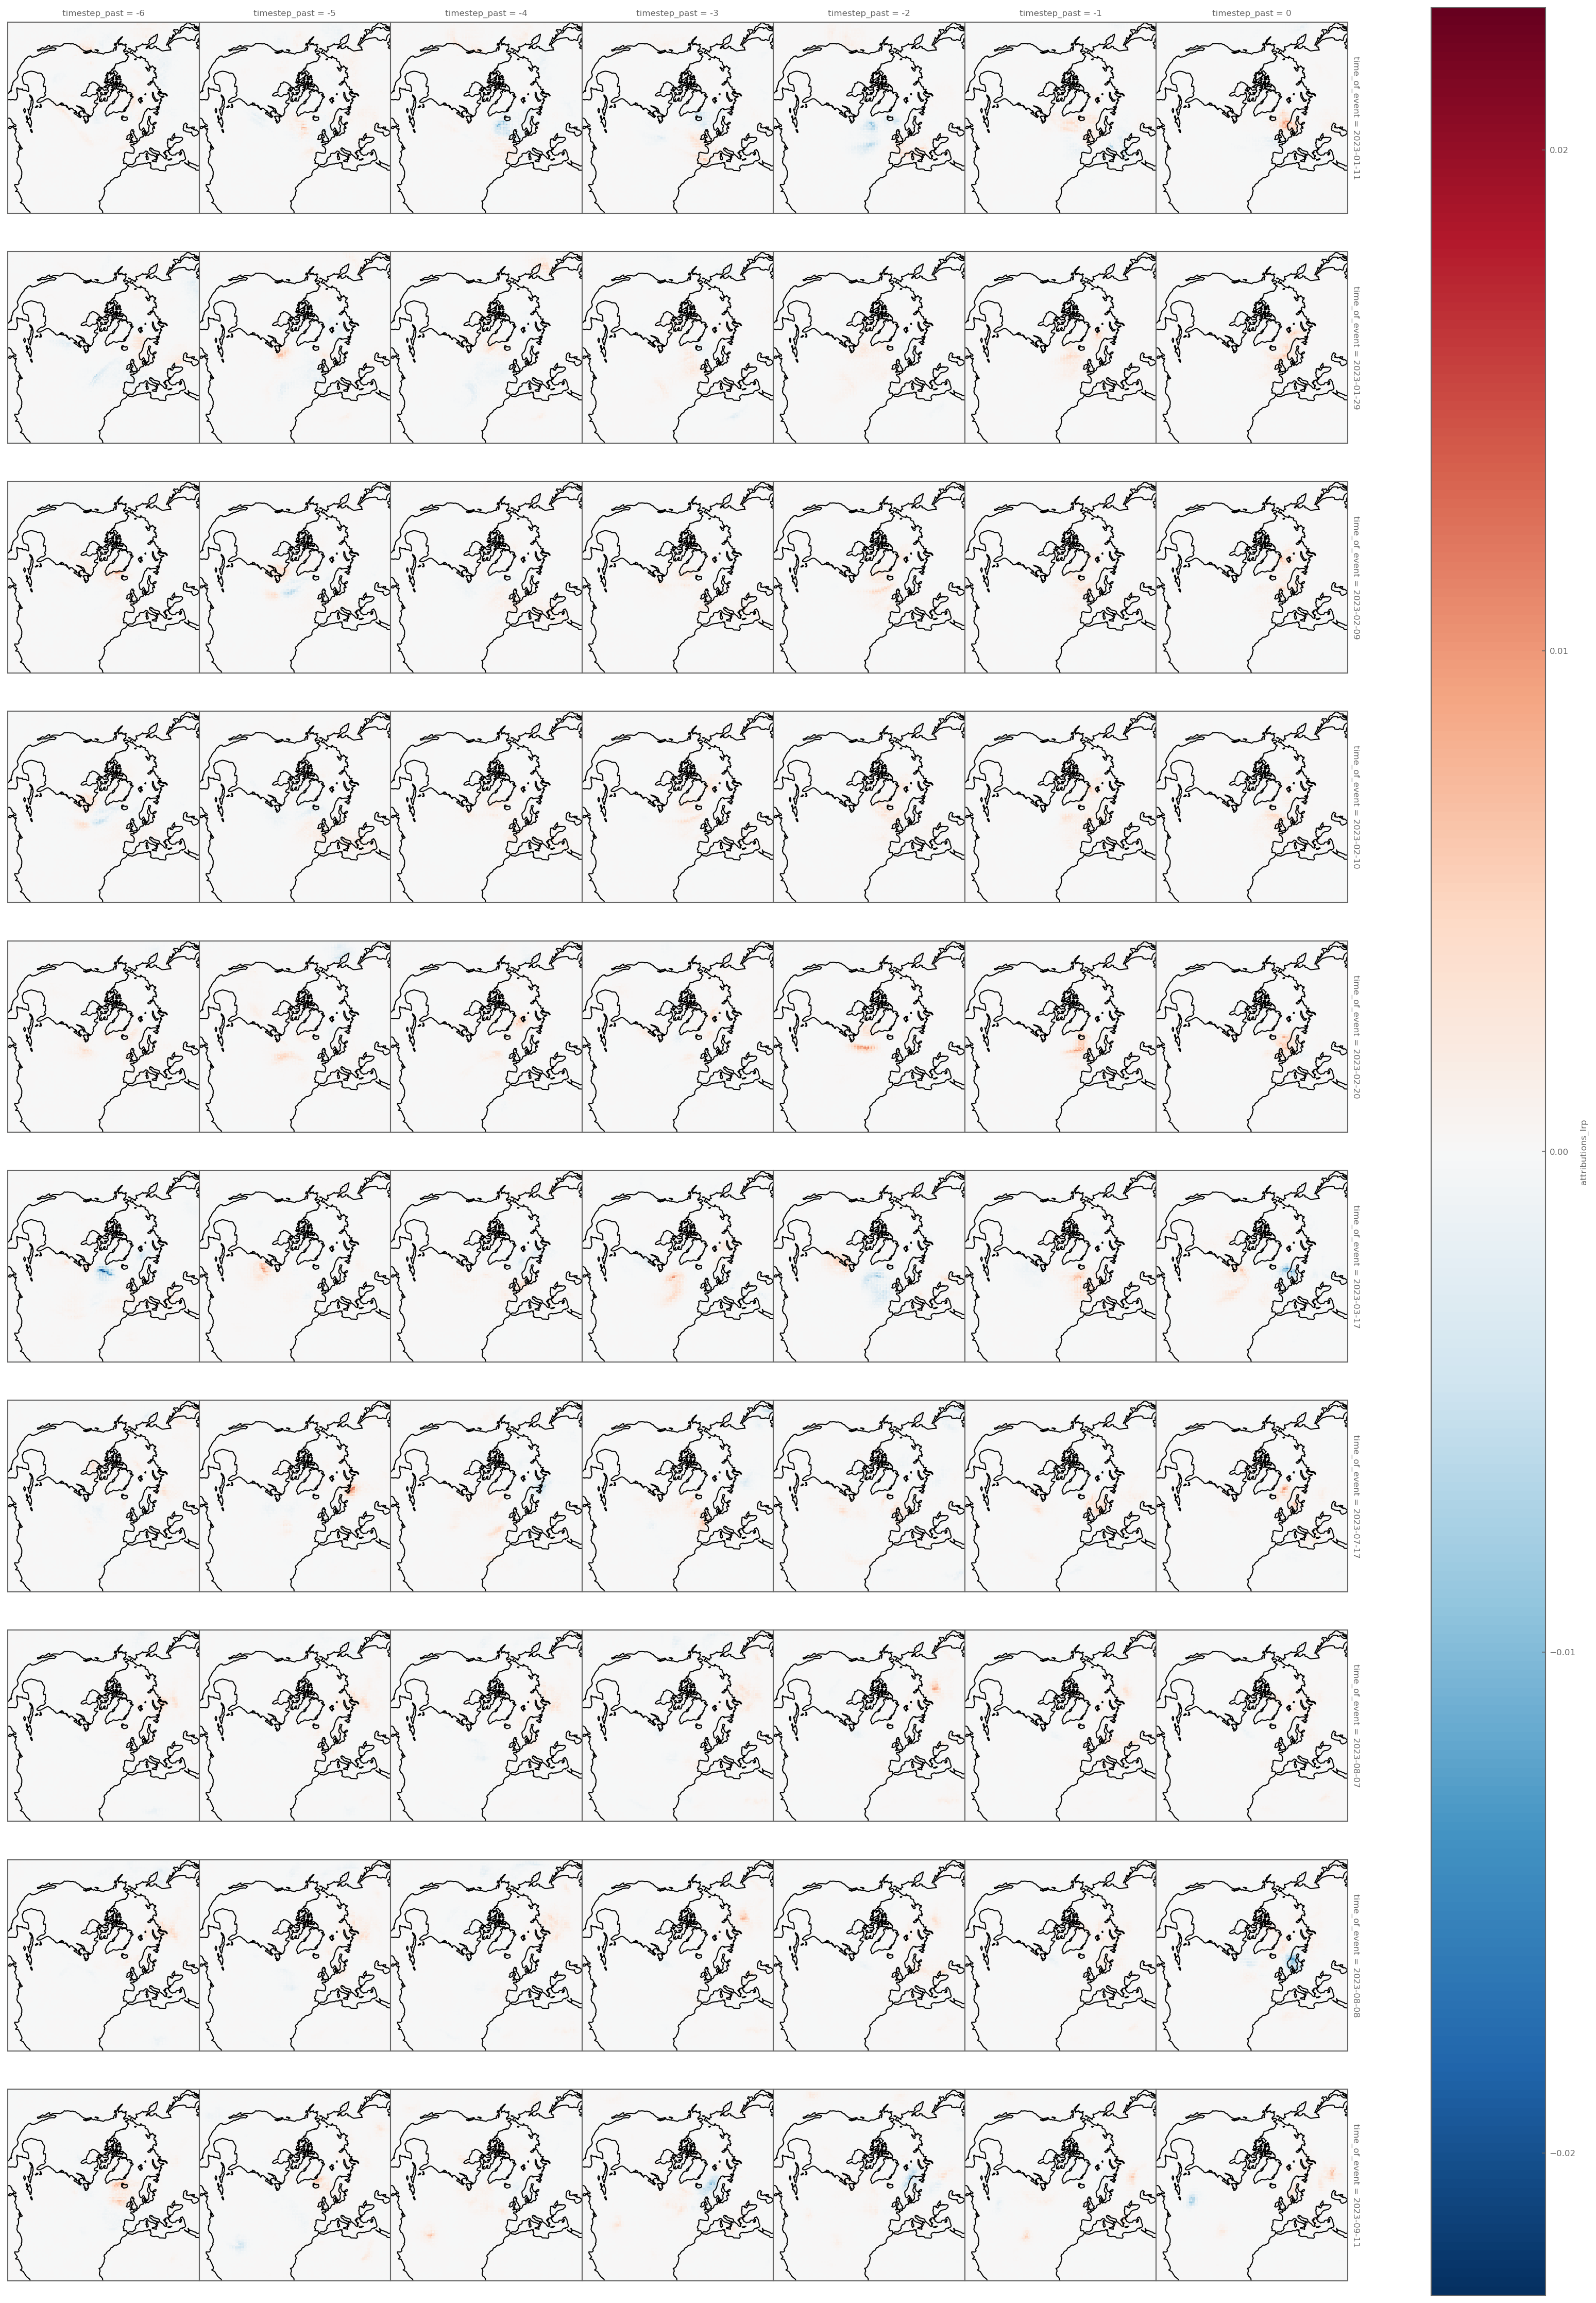

In [94]:
plot = lrp_normed.sel(time_of_event=slice('2022',None)).isel(time_of_event=range(20,30)).plot(col='timestep_past', subplot_kws = dict(projection=proj), transform=proj, row='time_of_event')
for ax in plot.axs.flat:
    ax.coastlines()

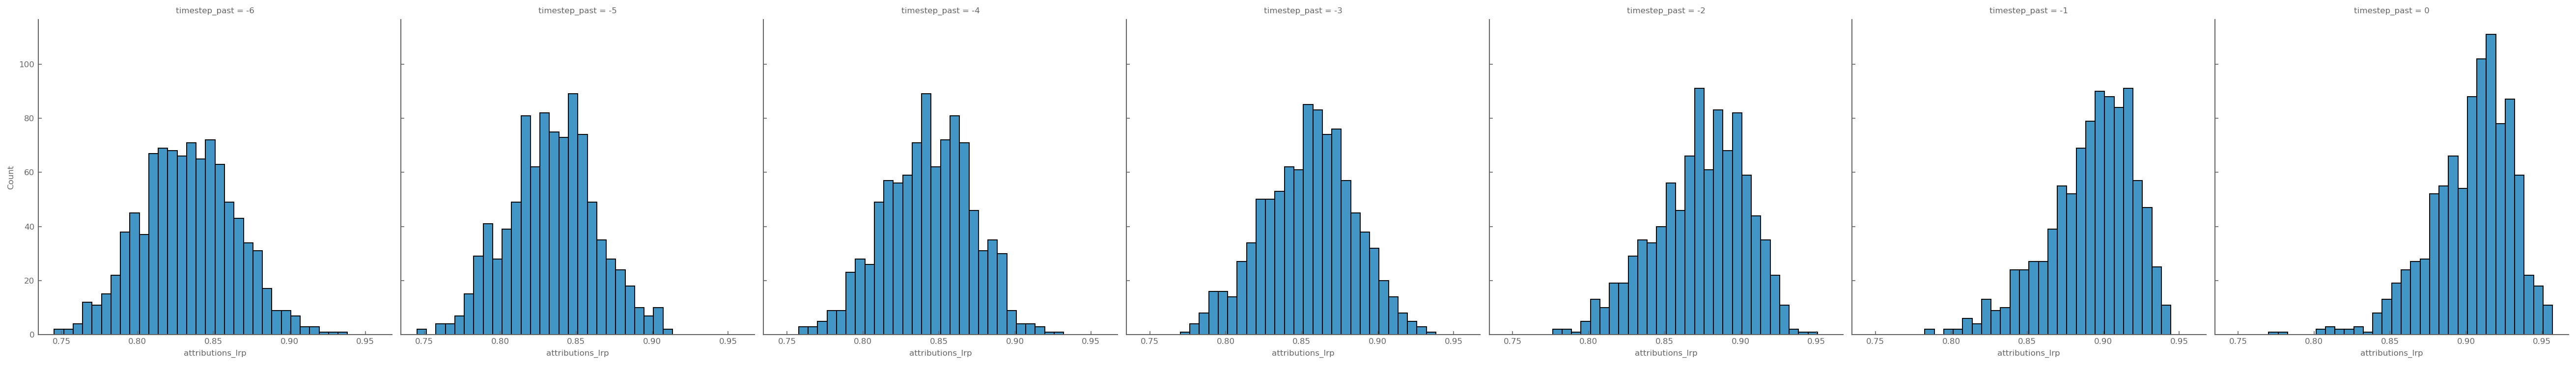

In [28]:
sns.displot(lrp_gini.to_series().reset_index(),x='attributions_lrp', col='timestep_past')

In [19]:
gini(lrp_normed.sel(time_of_event=slice('2020',None)).isel(time_of_event=0, timestep_past=0))

np.float64(-0.1721044565184644)

In [4]:
ds_event = ds_attrs.sel(time_of_event='2016-08-09')

In [33]:
wind_speed = np.sqrt(ds_event.features.sel(var_name='u850')**2 + ds_event.features.sel(var_name='v850')**2)*3.6

In [27]:
ds_event.features.sel(var_name=['u850','v850'])#to_dataset('var_name')

<xarray.DataArray 'features' (y: 128, x: 128, timestep_past: 7, var_name: 2)> Size: 918kB
array([[[[-4.47072238e-01,  2.00342536e-01],
         [-3.82108182e-01,  5.43295324e-01],
         [-3.13923955e-01,  8.04404497e-01],
         ...,
         [ 1.58310860e-01,  2.94056505e-01],
         [ 1.74043104e-01,  2.11354688e-01],
         [ 1.64236397e-01, -2.06928328e-01]],

        [[-3.69779110e-01,  1.80533439e-01],
         [-3.45611662e-01,  5.58989406e-01],
         [-2.22168148e-01,  7.70537853e-01],
         ...,
         [ 2.82646835e-01,  2.11172998e-01],
         [ 1.58367887e-01,  6.49086237e-02],
         [ 1.13835484e-01, -2.39900663e-01]],

        [[-3.59409809e-01,  2.20987469e-01],
         [-4.36510473e-01,  6.48792744e-01],
         [-2.10591808e-01,  7.62209833e-01],
         ...,
...
         [-1.73660874e+00, -1.01168346e+00],
         [-1.74624488e-01, -1.14170098e+00],
         [ 9.42723230e-02, -3.11866760e-01]],

        [[-8.29755485e-01, -3.97612482e-01],
         [-1.13057232e+00,  4.87241708e-02],
         [-1.23456073e+00,  4.30813134e-02],
         ...,
         [-1.52288902e+00, -7.24977434e-01],
         [-4.96854067e-01, -9.57433641e-01],
         [-2.32860267e-01, -1.34578332e-01]],

        [[-8.94644976e-01, -4.90522921e-01],
         [-1.14793658e+00, -2.83296015e-02],
         [-1.34881413e+00,  6.83134943e-02],
         ...,
         [-1.32841504e+00, -5.48774719e-01],
         [-8.11015069e-01, -4.53165919e-01],
         [-5.04007638e-01,  5.57334833e-02]]]],
      shape=(128, 128, 7, 2), dtype=float32)
Coordinates:
    quantile       float64 8B 0.95
  * y              (y) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * x              (x) float64 1kB -1e+07 -9.882e+06 ... 4.824e+06 4.941e+06
  * var_name       (var_name) <U4 32B 'u850' 'v850'
    lat            (y, x) float32 66kB -7.882 -7.546 -7.21 ... 32.25 31.67 31.09
    lon            (y, x) float32 66kB -45.0 -44.66 -44.32 ... 136.4 135.7 135.0
  * timestep_past  (timestep_past) int64 56B -6 -5 -4 -3 -2 -1 0
    time_of_event  datetime64[ns] 8B 2016-08-09

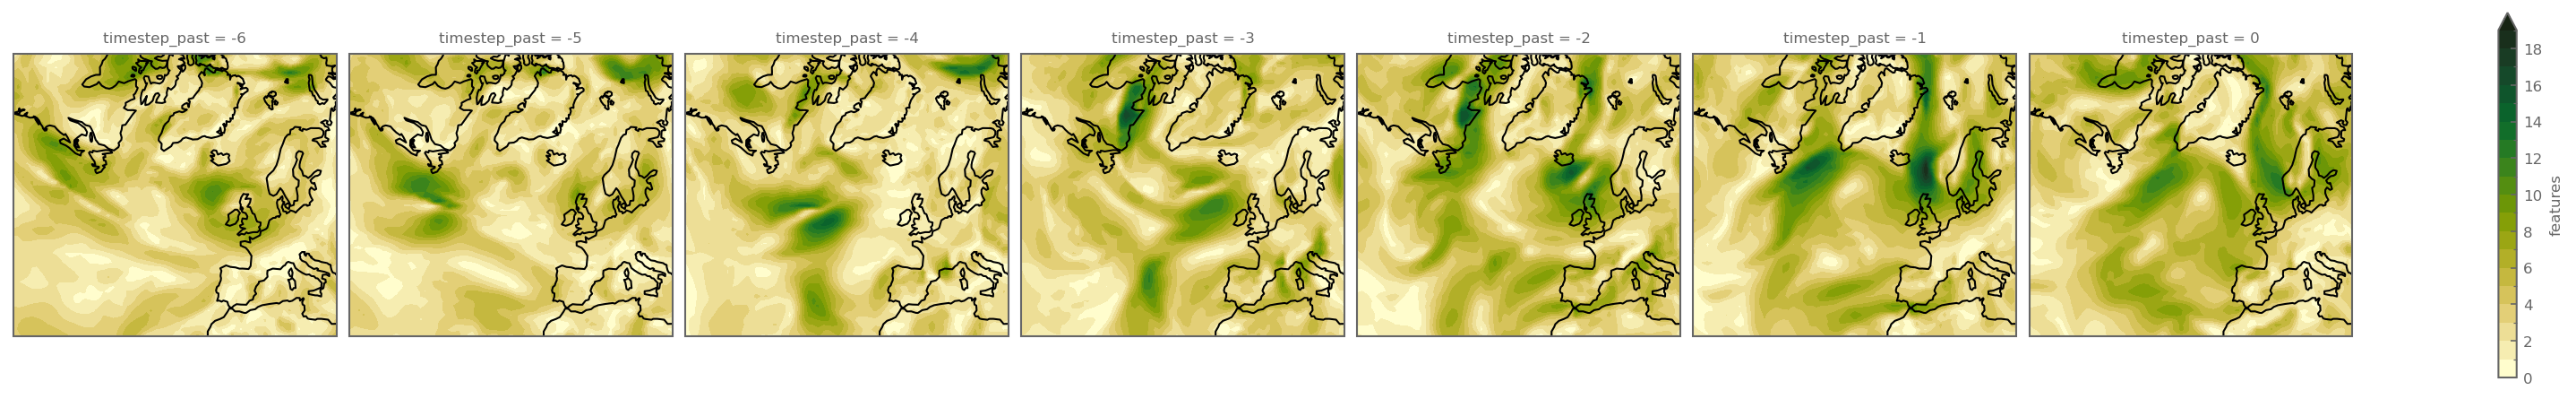

In [37]:
plot = wind_speed.plot.contourf(col='timestep_past', subplot_kws=dict(projection=proj), transform=proj, levels=np.arange(20), cmap=cm.speed)
for ax in plot.axs.flat:
    ax.coastlines()
    ax.set_extent((-6e6,2e6, -7e6, 0), crs=proj)

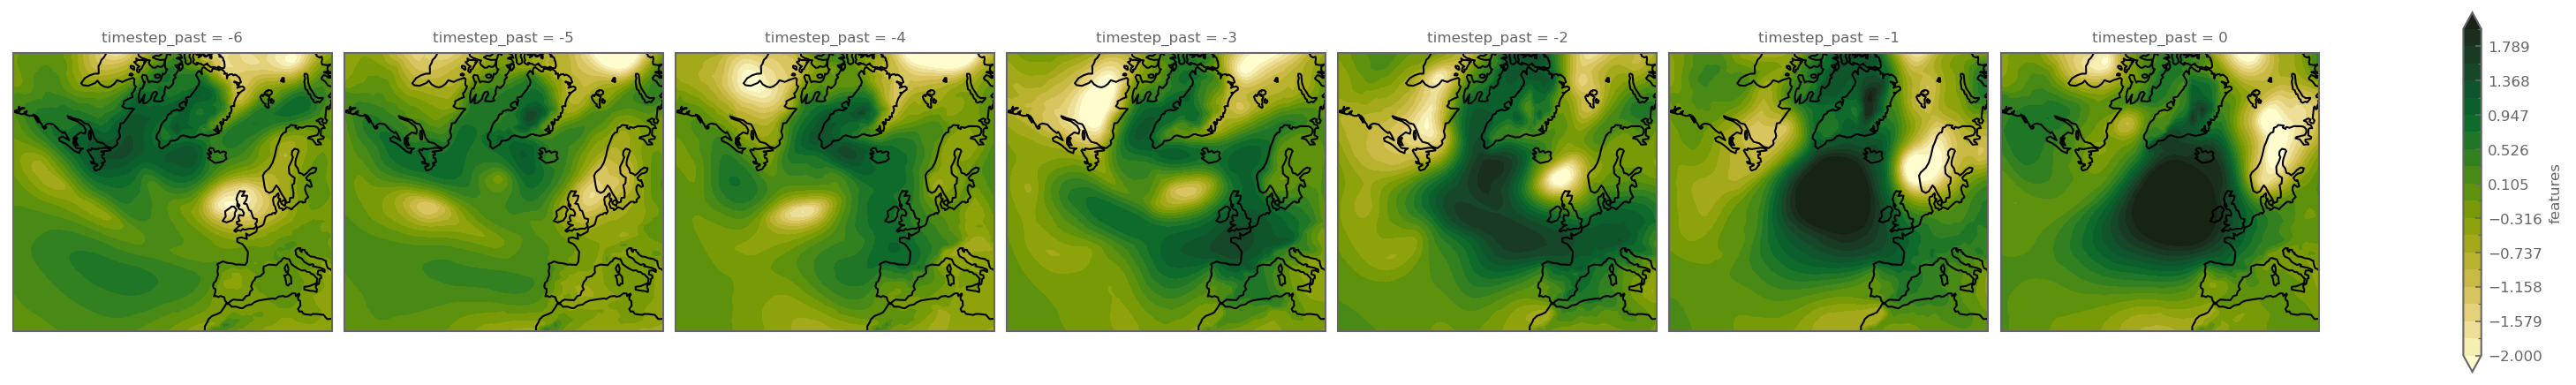

In [41]:
plot = ds_event.features.sel(var_name='msl').plot.contourf(col='timestep_past', subplot_kws=dict(projection=proj), transform=proj, cmap=cm.speed, levels=20, vmax=2)
for ax in plot.axs.flat:
    ax.coastlines()
    ax.set_extent((-6e6,2e6, -7e6, 0), crs=proj)